# Coleta e Atualizacao de Dados BCB

Este notebook gerencia a base de dados historicos dos indicadores economicos do Banco Central.

**Funcionalidades:**
- Download inicial: Busca historico completo (maximo disponivel na API)
- Atualizacao incremental: Busca apenas dados novos desde ultima atualizacao
- Consolidacao: Gera arquivos consolidados para analise rapida

**Indicadores:**
- IBC-Br (Bruto e Dessazonalizado)
- IGP-M
- Meta Selic
- Dolar/Euro PTAX
- CDI

## 1. Setup e Configuracao

In [1]:
import sys
from pathlib import Path
import pandas as pd
from datetime import datetime, timedelta
from bcb import sgs

# Add project root to path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.bcb_client import BCBClient
from src.data_manager import DataManager

# Inicializar componentes
data_path = project_root / 'data'
client = BCBClient()
data_manager = DataManager(data_path)

print("Componentes inicializados com sucesso!")
print(f"Diretorio de dados: {data_path}")

Componentes inicializados com sucesso!
Diretorio de dados: c:\Users\Enzo\Documents\Programming\dados-bcb\data


## 2. Configuracao dos Indicadores

In [2]:
INDICATORS_CONFIG = {
    'ibc_br_bruto': {
        'name': 'IBC-Br Bruto',
        'sgs_code': 24363,
        'frequency': 'monthly'
    },
    'ibc_br_dessaz': {
        'name': 'IBC-Br Dessazonalizado',
        'sgs_code': 24364,
        'frequency': 'monthly'
    },
    'igp_m': {
        'name': 'IGP-M Mensal',
        'sgs_code': 189,
        'frequency': 'monthly'
    },
    'selic': {
        'name': 'Meta Selic',
        'sgs_code': 432,
        'frequency': 'daily'
    },
    'dolar_ptax': {
        'name': 'Dolar PTAX Venda',
        'sgs_code': 10813,
        'frequency': 'daily'
    },
    'euro_ptax': {
        'name': 'Euro PTAX Venda',
        'sgs_code': 21619,
        'frequency': 'daily'
    },
    'cdi': {
        'name': 'CDI Diario',
        'sgs_code': 12,
        'frequency': 'daily'
    }
}

print(f"Total de indicadores configurados: {len(INDICATORS_CONFIG)}")
print(f"Mensais: {sum(1 for c in INDICATORS_CONFIG.values() if c['frequency'] == 'monthly')}")
print(f"Diarios: {sum(1 for c in INDICATORS_CONFIG.values() if c['frequency'] == 'daily')}")

Total de indicadores configurados: 7
Mensais: 3
Diarios: 4


## 3. Funcoes Auxiliares

In [3]:
def download_historical(indicator_key, config):
    """
    Download completo de dados historicos (maximo disponivel na API).
    
    Para series diarias: baixa em chunks de 10 anos (limite da API)
    Para series mensais: baixa tudo de uma vez
    
    Args:
        indicator_key: Identificador unico do indicador
        config: Dicionario de configuracao do indicador
    
    Returns:
        DataFrame com dados ou None se nao houver dados
    """
    print(f"Baixando {config['name']} (historico completo)...")
    
    if config['frequency'] == 'monthly':
        # Series mensais: pode pegar tudo de uma vez
        df = sgs.get({config['name']: config['sgs_code']}, start='1980-01-01')
    else:
        # Series diarias: limite de 10 anos por consulta
        # Baixar em chunks e concatenar
        chunks = []
        current_year = datetime.now().year
        
        # Baixar de 10 em 10 anos (de 1980 ate hoje)
        for start_year in range(1980, current_year + 1, 10):
            end_year = min(start_year + 9, current_year)
            start_date = f'{start_year}-01-01'
            end_date = f'{end_year}-12-31'
            
            try:
                chunk = sgs.get(
                    {config['name']: config['sgs_code']}, 
                    start=start_date, 
                    end=end_date
                )
                if not chunk.empty:
                    chunks.append(chunk)
                    print(f"    {start_year}-{end_year}: {len(chunk):,} registros")
            except Exception as e:
                # Ignorar erros de periodos sem dados
                pass
        
        if chunks:
            df = pd.concat(chunks)
            df = df[~df.index.duplicated(keep='last')]  # Remover duplicatas
            df = df.sort_index()
        else:
            df = pd.DataFrame()

    if df.empty:
        print(f"  Sem dados disponiveis")
        return None

    # Renomear coluna para 'value'
    df = df.rename(columns={config['name']: 'value'})

    # Salvar
    data_manager.save_indicator(
        df, indicator_key, config['frequency'],
        metadata={'sgs_code': config['sgs_code'], 'name': config['name']}
    )

    print(f"  Total: {len(df):,} registros salvos ({df.index.min().date()} a {df.index.max().date()})")
    return df


def update_incremental(indicator_key, config):
    """
    Atualizacao incremental - busca apenas dados novos.
    
    Args:
        indicator_key: Identificador unico do indicador
        config: Dicionario de configuracao do indicador
    
    Returns:
        DataFrame com novos dados ou None se nao houver
    """
    last_date = data_manager.get_last_date(indicator_key, config['frequency'])

    if last_date is None:
        print(f"{config['name']}: Arquivo nao existe. Use download_historical() primeiro.")
        return None

    # Calcular periodo de atualizacao
    if config['frequency'] == 'daily':
        start_date = last_date + timedelta(days=1)
    else:  # monthly
        # Proximo primeiro dia do mes
        start_date = (last_date.replace(day=1) + timedelta(days=32)).replace(day=1)

    end_date = datetime.now()

    if start_date > end_date:
        print(f"{config['name']}: Ja atualizado")
        return None

    print(f"Atualizando {config['name']} desde {start_date.date()}...")
    
    df = sgs.get({config['name']: config['sgs_code']}, start=start_date.strftime('%Y-%m-%d'))

    if df.empty:
        print(f"  Sem dados novos")
        return None

    df = df.rename(columns={config['name']: 'value'})
    data_manager.append_indicator(df, indicator_key, config['frequency'])

    print(f"  {len(df):,} novos registros")
    return df

print("Funcoes auxiliares carregadas!")

Funcoes auxiliares carregadas!


## 4. Download Inicial ou Atualizacao

Esta celula detecta automaticamente se e a primeira execucao ou uma atualizacao.

In [4]:
# Detectar modo de execucao
is_first_run = not (data_path / 'raw' / 'daily').exists()

if is_first_run:
    print("=" * 70)
    print("PRIMEIRA EXECUCAO - Download de Historico Completo")
    print("Buscando maximo disponivel na API do BCB")
    print("=" * 70)
    print("\nEste processo pode levar alguns minutos...\n")

    for key, config in INDICATORS_CONFIG.items():
        download_historical(key, config)
        print()  # Linha em branco

else:
    print("=" * 70)
    print("ATUALIZACAO INCREMENTAL")
    print("Buscando apenas dados novos desde a ultima atualizacao")
    print("=" * 70)
    print()

    for key, config in INDICATORS_CONFIG.items():
        update_incremental(key, config)

print("\n" + "=" * 70)
print("Coleta de dados concluida!")
print("=" * 70)

PRIMEIRA EXECUCAO - Download de Historico Completo
Buscando maximo disponivel na API do BCB

Este processo pode levar alguns minutos...

Baixando IBC-Br Bruto (historico completo)...
  Total: 273 registros salvos (2003-01-01 a 2025-09-01)

Baixando IBC-Br Dessazonalizado (historico completo)...
  Total: 273 registros salvos (2003-01-01 a 2025-09-01)

Baixando IGP-M Mensal (historico completo)...
  Total: 437 registros salvos (1989-07-01 a 2025-11-01)

Baixando Meta Selic (historico completo)...
    2010-2019: 3,652 registros
    2020-2025: 2,171 registros
  Total: 5,823 registros salvos (2010-01-01 a 2025-12-10)

Baixando Dolar PTAX Venda (historico completo)...
    1980-1989: 1,271 registros
    1990-1999: 2,496 registros
    2000-2009: 2,512 registros
    2010-2019: 2,512 registros
  Total: 8,791 registros salvos (1984-11-28 a 2019-12-31)

Baixando Euro PTAX Venda (historico completo)...
    1990-1999: 251 registros
  Total: 251 registros salvos (1998-12-31 a 1999-12-31)

Baixando CD

## 5. Consolidacao

Gera arquivos consolidados para facilitar analises.

In [5]:
print("=" * 70)
print("CONSOLIDANDO DADOS")
print("=" * 70)
print()

# Consolidar indicadores mensais
df_monthly = data_manager.consolidate_monthly()

if not df_monthly.empty:
    # Salvar consolidado
    (data_path / 'processed').mkdir(parents=True, exist_ok=True)
    df_monthly.to_parquet(
        data_path / 'processed' / 'monthly_consolidated.parquet',
        engine='pyarrow',
        compression='snappy'
    )
    print(f"Dados mensais consolidados: {df_monthly.shape[0]:,} registros x {df_monthly.shape[1]} indicadores")
    print(f"  Periodo: {df_monthly.index.min().date()} a {df_monthly.index.max().date()}")
else:
    print("Nenhum dado mensal encontrado")

print()

# Consolidar indicadores diarios
df_daily = data_manager.consolidate_daily()

if not df_daily.empty:
    # Salvar consolidado
    (data_path / 'processed').mkdir(parents=True, exist_ok=True)
    df_daily.to_parquet(
        data_path / 'processed' / 'daily_consolidated.parquet',
        engine='pyarrow',
        compression='snappy'
    )
    print(f"Dados diarios consolidados: {df_daily.shape[0]:,} registros x {df_daily.shape[1]} indicadores")
    print(f"  Periodo: {df_daily.index.min().date()} a {df_daily.index.max().date()}")
else:
    print("Nenhum dado diario encontrado")

print("\n" + "=" * 70)
print("Consolidacao concluida!")
print("=" * 70)

CONSOLIDANDO DADOS

Dados mensais consolidados: 437 registros x 3 indicadores
  Periodo: 1989-07-01 a 2025-11-01

Dados diarios consolidados: 12,102 registros x 4 indicadores
  Periodo: 1984-11-28 a 2025-12-10

Consolidacao concluida!


## 6. Resumo dos Dados

In [6]:
print("=" * 70)
print("RESUMO DOS DADOS COLETADOS")
print("=" * 70)
print()

# Verificar cada indicador
for key, config in INDICATORS_CONFIG.items():
    df = data_manager.read_indicator(key, config['frequency'])
    
    if not df.empty:
        first_date = df.index.min()
        last_date = df.index.max()
        total_records = len(df)
        
        print(f"{config['name']:30s} | {first_date.date()} a {last_date.date()} | {total_records:6,} registros")
    else:
        print(f"{config['name']:30s} | Sem dados")

print("\n" + "=" * 70)

RESUMO DOS DADOS COLETADOS

IBC-Br Bruto                   | 2003-01-01 a 2025-09-01 |    273 registros
IBC-Br Dessazonalizado         | 2003-01-01 a 2025-09-01 |    273 registros
IGP-M Mensal                   | 1989-07-01 a 2025-11-01 |    437 registros
Meta Selic                     | 2010-01-01 a 2025-12-10 |  5,823 registros
Dolar PTAX Venda               | 1984-11-28 a 2019-12-31 |  8,791 registros
Euro PTAX Venda                | 1998-12-31 a 1999-12-31 |    251 registros
CDI Diario                     | 1986-03-06 a 2025-12-01 |  9,944 registros



## 7. Visualizacao Rapida

Visualizacao dos dados mais recentes.

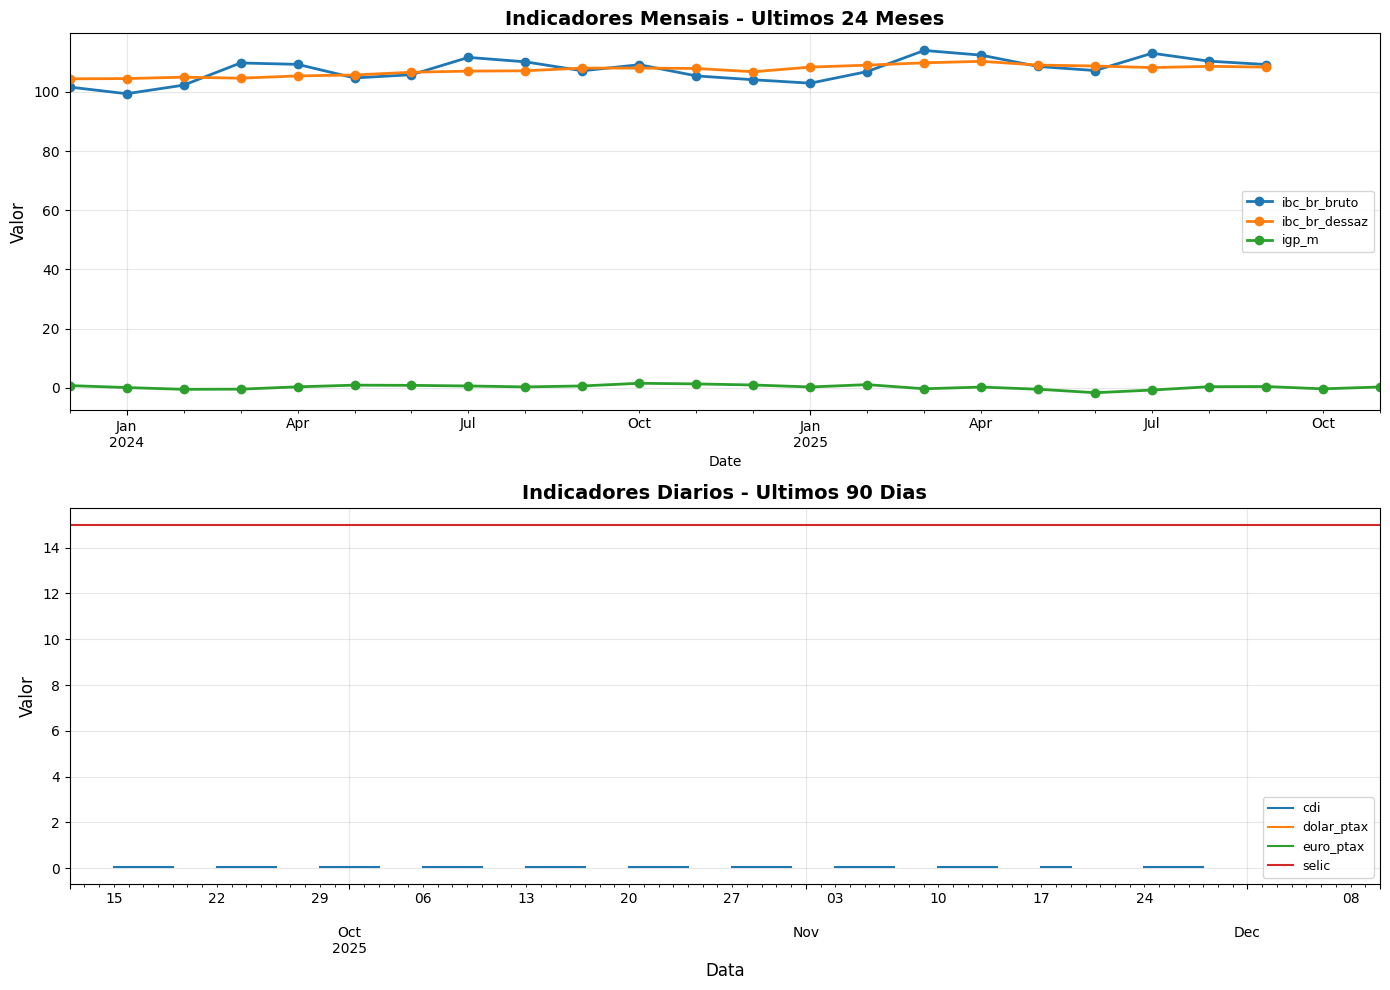


Atualizacao concluida com sucesso!


In [7]:
import matplotlib.pyplot as plt

if not df_monthly.empty and not df_daily.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Mensais - ultimos 24 meses
    df_monthly.tail(24).plot(ax=axes[0], marker='o', linewidth=2)
    axes[0].set_title('Indicadores Mensais - Ultimos 24 Meses',
                     fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Valor', fontsize=12)
    axes[0].legend(fontsize=9, loc='best')
    axes[0].grid(True, alpha=0.3)

    # Diarios - ultimos 90 dias
    df_daily.tail(90).plot(ax=axes[1], linewidth=1.5)
    axes[1].set_title('Indicadores Diarios - Ultimos 90 Dias',
                     fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Valor', fontsize=12)
    axes[1].set_xlabel('Data', fontsize=12)
    axes[1].legend(fontsize=9, loc='best')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    print("\nAtualizacao concluida com sucesso!")
else:
    print("Dados insuficientes para visualizacao. Execute a celula 4 primeiro.")

## Como Usar Este Notebook

### Primeira Execucao (Setup Inicial)
1. Execute todas as celulas em sequencia (Shift+Enter)
2. Aguarde o download completo do historico (3-10 minutos)
3. Os dados serao salvos em `data/raw/` e consolidados em `data/processed/`

### Atualizacoes Diarias (Rotina)
1. Execute todas as celulas em sequencia
2. Apenas dados novos serao baixados (10-30 segundos)
3. Os arquivos consolidados serao atualizados automaticamente

### Leitura de Dados em Outros Notebooks
```python
import pandas as pd

# Ler consolidados
df_daily = pd.read_parquet('data/processed/daily_consolidated.parquet')
df_monthly = pd.read_parquet('data/processed/monthly_consolidated.parquet')

# Ou usar DataManager para indicadores individuais
from pathlib import Path
from src.data_manager import DataManager

data_manager = DataManager(Path('data'))
df_dolar = data_manager.read_indicator('dolar_ptax', 'daily')
```